## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_excel("Sample - Superstore 2019.xls")
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [3]:
print("Shape:", df.shape)
df.info(memory_usage="deep")

Shape: (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 1

In [4]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9983.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2019-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,NaN,NaN,NaN,NaN,NaN,NaN,...,55245.233297,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2016-01-03 00:00:00,2016-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2017-05-23 00:00:00,2017-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2018-06-26 00:00:00,2018-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,57103.000000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2019-05-14 00:00:00,2019-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2019-12-30 00:00:00,2020-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df[df.duplicated(subset=["Order ID", "Product Name"], keep=False)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
350,351,CA-2018-129714,2018-09-01,2018-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,10009.0,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,24.560,2,0.0,11.5432
352,353,CA-2018-129714,2018-09-01,2018-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,10009.0,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,49.120,4,0.0,23.0864
430,431,US-2018-123750,2018-04-15,2018-04-21,Standard Class,RB-19795,Ross Baird,Home Office,United States,Gastonia,...,28052.0,South,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,408.744,7,0.2,76.6395
431,432,US-2018-123750,2018-04-15,2018-04-21,Standard Class,RB-19795,Ross Baird,Home Office,United States,Gastonia,...,28052.0,South,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,291.960,5,0.2,54.7425
1300,1301,CA-2018-137043,2018-12-23,2018-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,22153.0,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",572.760,6,0.0,166.1004
1301,1302,CA-2018-137043,2018-12-23,2018-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,22153.0,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",286.380,3,0.0,83.0502
3183,3184,CA-2019-152912,2019-11-09,2019-11-12,Second Class,BM-11650,Brian Moss,Corporate,United States,Columbia,...,21044.0,East,OFF-ST-10003208,Office Supplies,Storage,Adjustable Depth Letter/Legal Cart,1633.140,9,0.0,473.6106
3184,3185,CA-2019-152912,2019-11-09,2019-11-12,Second Class,BM-11650,Brian Moss,Corporate,United States,Columbia,...,21044.0,East,OFF-ST-10003208,Office Supplies,Storage,Adjustable Depth Letter/Legal Cart,544.380,3,0.0,157.8702
3405,3406,US-2016-150119,2016-04-23,2016-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229.0,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
3406,3407,US-2016-150119,2016-04-23,2016-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229.0,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


## 3. Data Cleaning & Reusable Preprocessing

In [6]:
def preprocess_data(df):
    df = df.copy()

    # Convert dates
    df[["Order Date", "Ship Date"]] = df[["Order Date", "Ship Date"]].apply(pd.to_datetime)

    # Remove unnecessary column and exact duplicate rows
    df.drop(columns="Row ID", inplace=True)
    df.drop_duplicates(inplace=True)

    # Handle missing Postal Code
    df["Postal Code"] = df["Postal Code"].fillna("05408").astype("str")

    # Standardize text formatting
    text_cols = df.select_dtypes(include=["object", "string"]).columns
    df[text_cols] = df[text_cols].apply(lambda col: col.str.strip().str.title())

    # Optimize categorical columns
    category_cols = [
        "Order ID", "Ship Mode", "Customer ID", "Segment",
        "Country/Region", "City", "State", "Region",
        "Product ID", "Category", "Sub-Category"
    ]
    df[category_cols] = df[category_cols].astype("category")

    return df


def create_features(df):
    df = df.copy()

    df["Years"] = df["Order Date"].dt.year
    df["Months"] = df["Order Date"].dt.month_name().astype("category")
    df["Quarters"] = df["Order Date"].dt.quarter

    df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100
    df["Shipping Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

    df["Sales Performance Category"] = pd.qcut(
        df["Sales"],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    df["Discount_Buckets"] = pd.cut(
        df["Discount"],
        bins=[-0.01, 0, 0.2, 0.6, 0.8],
        labels=["No_Discount", "Low_Discount", "Medium_Discount", "High_Discount"]
    )

    return df

In [7]:
df_clean = preprocess_data(df)
df_clean = create_features(df_clean)

df_clean.info(memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order ID                    9993 non-null   category      
 1   Order Date                  9993 non-null   datetime64[us]
 2   Ship Date                   9993 non-null   datetime64[us]
 3   Ship Mode                   9993 non-null   category      
 4   Customer ID                 9993 non-null   category      
 5   Customer Name               9993 non-null   str           
 6   Segment                     9993 non-null   category      
 7   Country/Region              9993 non-null   category      
 8   City                        9993 non-null   category      
 9   State                       9993 non-null   category      
 10  Postal Code                 9993 non-null   str           
 11  Region                      9993 non-null   category      
 12  Product 

In [8]:
print("Missing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())
print("Negative shipping durations:", (df_clean["Shipping Duration"] < 0).sum())

Missing values:
Order ID                      0
Order Date                    0
Ship Date                     0
Ship Mode                     0
Customer ID                   0
Customer Name                 0
Segment                       0
Country/Region                0
City                          0
State                         0
Postal Code                   0
Region                        0
Product ID                    0
Category                      0
Sub-Category                  0
Product Name                  0
Sales                         0
Quantity                      0
Discount                      0
Profit                        0
Years                         0
Months                        0
Quarters                      0
Profit Margin                 0
Shipping Duration             0
Sales Performance Category    0
Discount_Buckets              0
dtype: int64

Duplicate rows: 0
Negative shipping durations: 0


## 4. Outlier Analysis

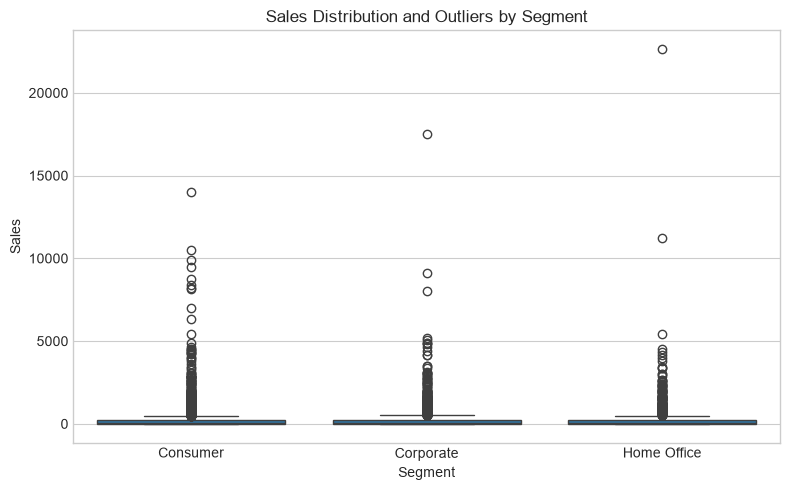

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Segment", y="Sales")
plt.title("Sales Distribution and Outliers by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [10]:
print(
    f'Min Discount: {df_clean["Discount"].min()} | '
    f'Max Discount: {df_clean["Discount"].max()}'
)

Min Discount: 0.0 | Max Discount: 0.8


## 5. Business Questions

1. Are sales growing over time?
2. Which products generate high sales but low profitability?
3. Do discounts affect profitability?
4. Which regions perform best in sales and profitability?
5. Which customer segment provides the highest RFM value?
6. Who are the highest-value customers?
7. Does shipping duration relate to financial performance?
8. Which factors are most strongly associated with profitability?

## 6. Analytical Preparation

In [11]:
Product_Analysis = df_clean.groupby("Product ID", observed=True).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

Product_Analysis["Product_Margin_Percent"] = (
    Product_Analysis["Total_Profit"] / Product_Analysis["Total_Sales"] * 100
)

Region_Profit = df_clean.groupby("Region", observed=True).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

Region_Profit["Region_Profit_Margin"] = (
    Region_Profit["Total_Profit"] / Region_Profit["Total_Sales"] * 100
)

Discount_Analysis = df_clean.groupby("Discount_Buckets", observed=True).agg(
    Total_Sales=("Sales", "sum"),    
    Total_Profit=("Profit", "sum")
)
    

In [12]:
Measurement_point = df_clean["Order Date"].max()

RFM = df_clean.groupby("Customer ID", observed=True).agg(
    Recency=("Order Date", lambda x: (Measurement_point - x.max()).days + 1),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum")
)

RFM["R_Score"] = pd.qcut(RFM["Recency"], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
RFM["F_Score"] = pd.qcut(RFM["Frequency"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
RFM["M_Score"] = pd.qcut(RFM["Monetary"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

RFM["Level_Of_Loyalty (3 to 15)"] = (
    RFM["R_Score"] + RFM["F_Score"] + RFM["M_Score"]
)

RFM["Segment"] = pd.cut(
    RFM["Level_Of_Loyalty (3 to 15)"],
    [3, 6, 9, 12, 15],
    labels=["At Risk", "Potential", "Loyal", "Champions"],
    include_lowest=True
)

RFM.sort_values("Recency").head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Level_Of_Loyalty (3 to 15),Segment
Customer ID,,,,,,,,
Jm-15580,1,5,303.948,5,2,1,8,Potential
Po-18865,1,7,2493.214,5,3,3,11,Loyal
Cc-12430,1,10,2870.050,5,5,4,14,Champions
Eb-13975,1,4,1643.255,5,1,2,8,Potential
Kh-16360,2,6,3100.612,5,3,4,12,Loyal
Jg-15160,2,11,6366.392,5,5,5,15,Champions
Kb-16600,2,7,983.922,5,3,2,10,Loyal
Bs-11755,2,7,2562.382,5,3,3,11,Loyal
Bp-11185,2,9,3675.861,5,5,4,14,Champions


## 7. EDA & Visualizations

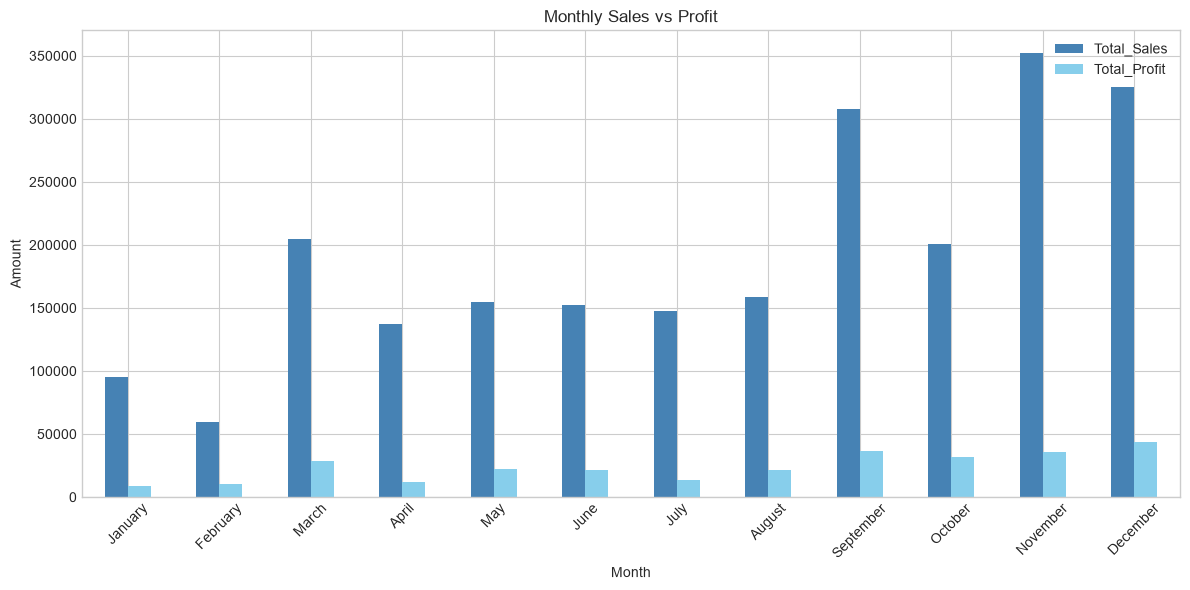

In [13]:
# 1. Monthly Sales vs Profit
sorted_months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_sales = df_clean.groupby("Months", observed=True).agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum")
).reindex(sorted_months)



monthly_sales.plot(kind="bar",figsize=(12, 6),color=["steelblue", "skyblue"])
plt.title("Monthly Sales vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

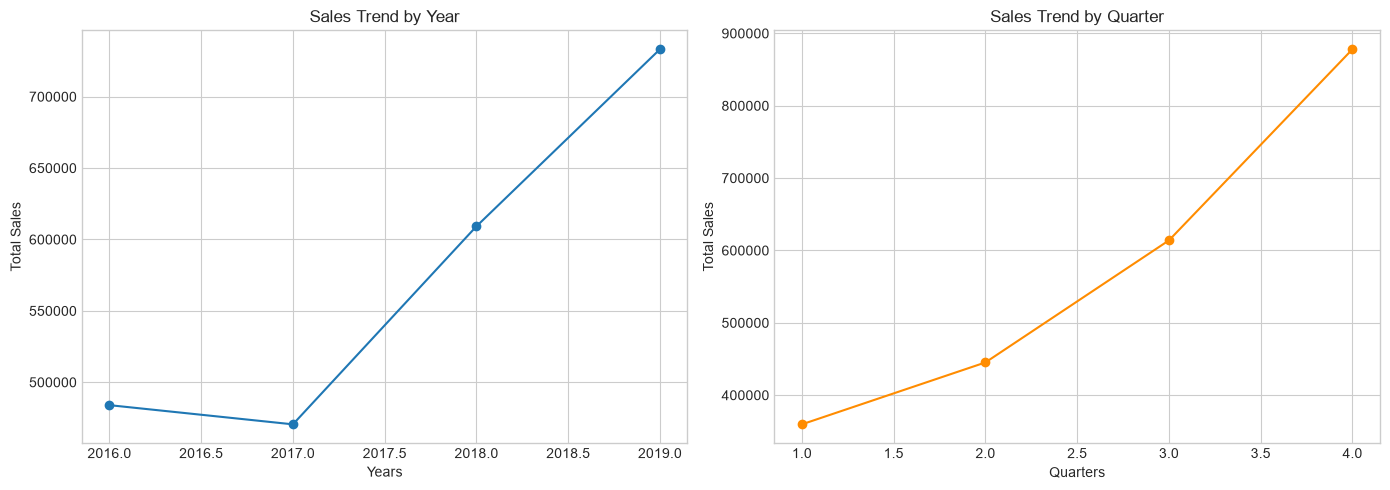

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.groupby("Years")["Sales"].sum().plot(kind="line", marker="o", ax=axes[0])
axes[0].set_title("Sales Trend by Year")
axes[0].set_ylabel("Total Sales")

df_clean.groupby("Quarters")["Sales"].sum().plot(kind="line", marker="o", ax=axes[1], color="darkorange")
axes[1].set_title("Sales Trend by Quarter")
axes[1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

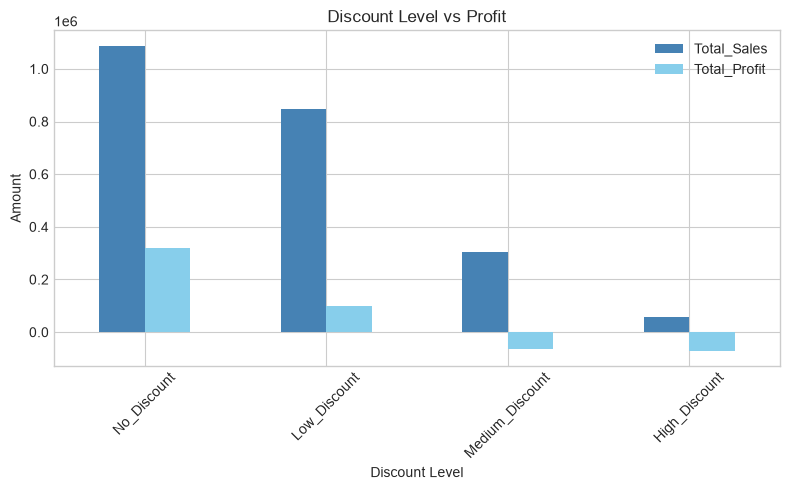

In [15]:
# 3. Discount Level vs Profit
Discount_Analysis.plot(kind="bar", figsize=(8, 5),color=["steelblue", "skyblue"])
plt.title("Discount Level vs Profit")
plt.xlabel("Discount Level")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

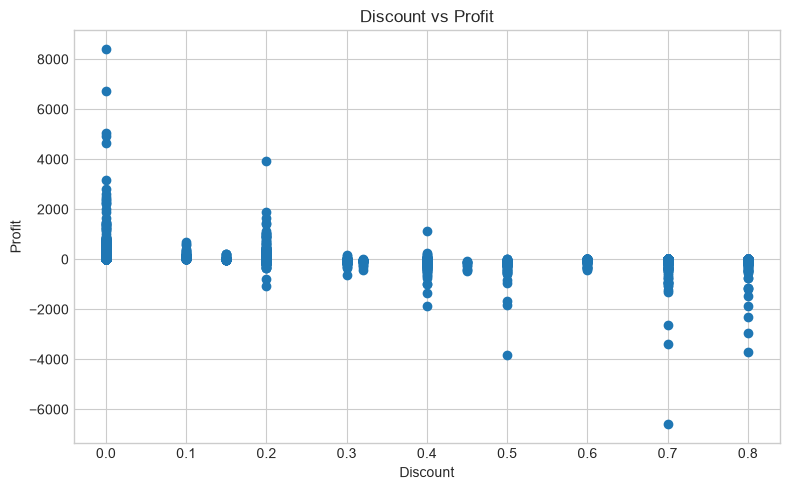

In [16]:
# 4. Discount vs Profit
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["Discount"], df_clean["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

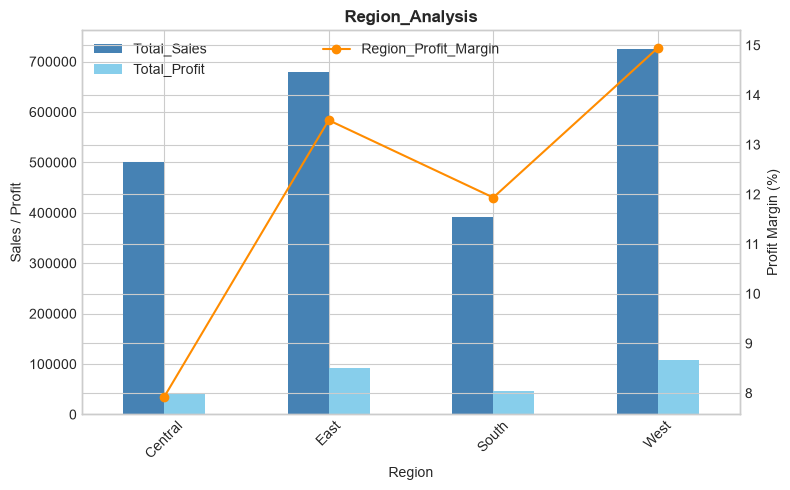

In [17]:
# 5. Sales, Profit by Region
fig, ax1 = plt.subplots(figsize=(8, 5))

Region_Profit[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    ax=ax1,
    color=["steelblue", "skyblue"]
)

ax1.set_ylabel("Sales / Profit")
ax1.set_xlabel("Region")

ax2 = ax1.twinx()

Region_Profit["Region_Profit_Margin"].plot(
    kind="line",
    marker="o",
    ax=ax2,
    color="darkorange"
)

ax2.set_ylabel("Profit Margin (%)")
ax2.legend(loc="upper center")
plt.title("Region_Analysis",fontweight="bold")
ax1.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

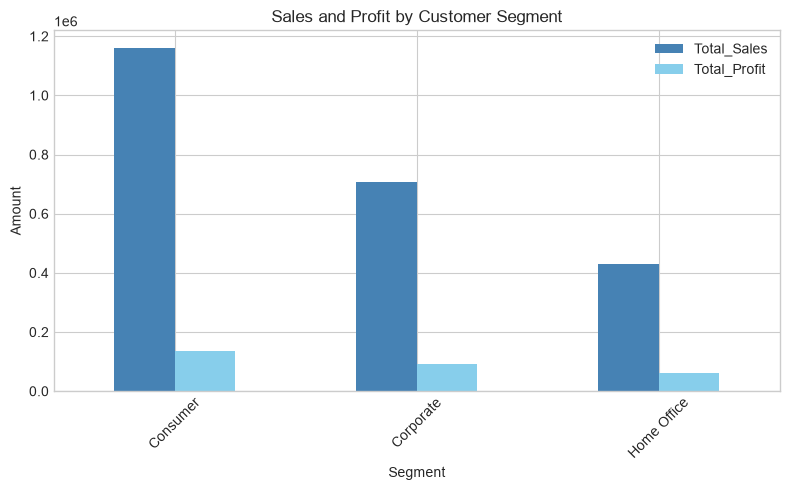

In [18]:
# 6. Sales and Profit by Customer Segment
Segment_Analysis = df_clean.groupby("Segment", observed=True).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

Segment_Analysis.plot(kind="bar", figsize=(8, 5),color=["steelblue", "skyblue"])
plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

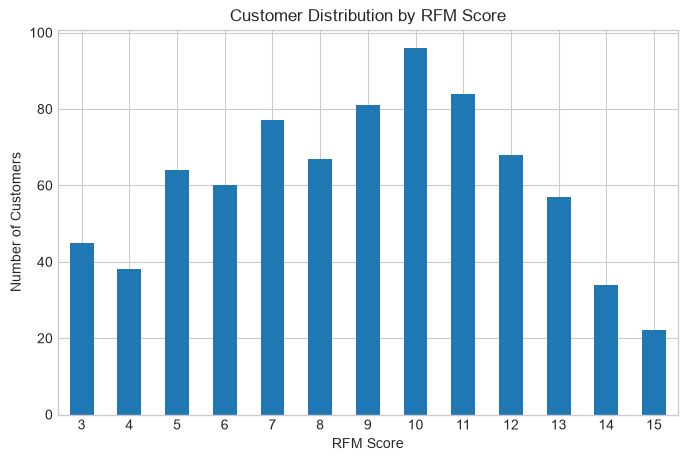

In [19]:
# 7. Customer Distribution by RFM Score
RFM["Level_Of_Loyalty (3 to 15)"].value_counts().sort_index().plot(
    kind="bar", figsize=(8, 5)
)
plt.title("Customer Distribution by RFM Score")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

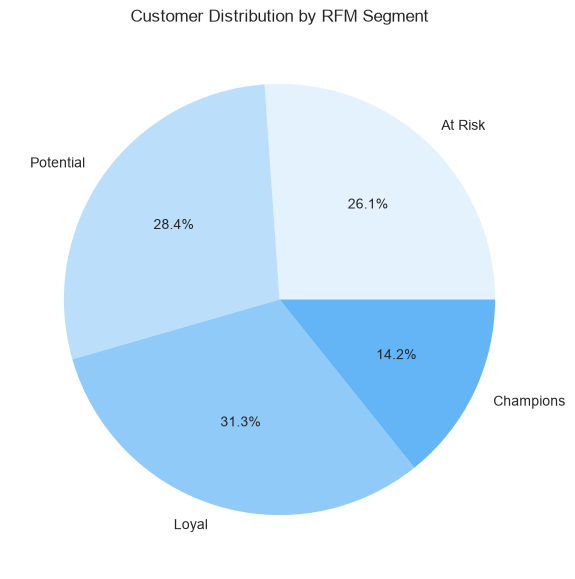

In [20]:
# 8. Customer Distribution by RFM Segment
RFM["Segment"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7),
    colors=["#E3F2FD", "#BBDEFB", "#90CAF9", "#64B5F6"]
)
plt.title("Customer Distribution by RFM Segment")
plt.ylabel("")
plt.show()

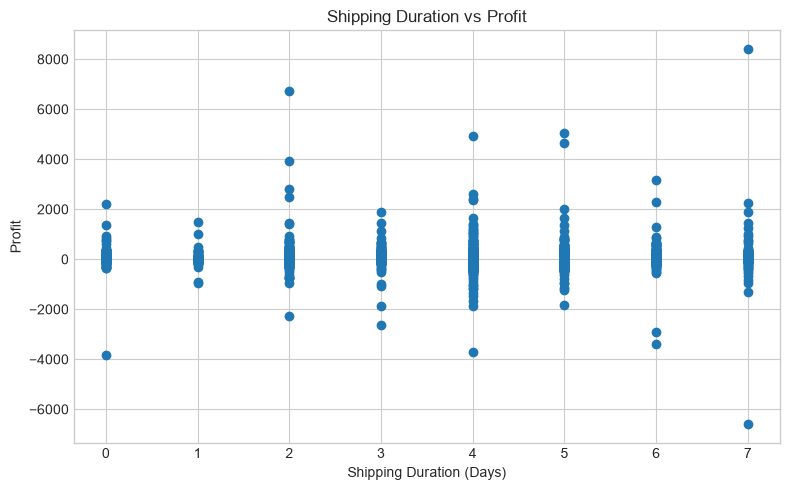

In [21]:
# 9. Shipping Duration vs Profit
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["Shipping Duration"], df_clean["Profit"])
plt.title("Shipping Duration vs Profit")
plt.xlabel("Shipping Duration (Days)")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

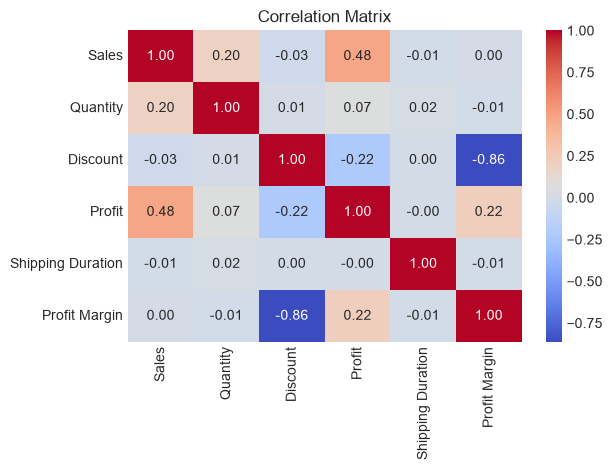

In [22]:
# 10. Correlation Analysis
numeric_cols = [
    "Sales", "Quantity", "Discount",
    "Profit", "Shipping Duration", "Profit Margin"
]

corr = df_clean[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Key Analytical Results

In [23]:
print("Top products by sales:")
display(Product_Analysis.sort_values("Total_Sales", ascending=False).head(10))

print("High-sales products with negative profit:")
display(
    Product_Analysis[
        Product_Analysis["Product_Margin_Percent"] < 0
    ].sort_values("Total_Sales", ascending=False).head(10)
)

Top products by sales:


,Total_Sales,Total_Profit,Product_Margin_Percent
Product ID,,,
Tec-Co-10004722,61599.824,2.519993e+04,4.090909e+01
Off-Bi-10003527,27453.384,7.753039e+03,2.824074e+01
Tec-Ma-10002412,22638.480,-1.811078e+03,-8.000000e+00
Fur-Ch-10002024,21870.576,3.979039e-13,1.819357e-15
Off-Bi-10001359,19823.479,2.233505e+03,1.126697e+01
Off-Bi-10000545,19024.500,7.609800e+02,4.000000e+00
Tec-Co-10001449,18839.686,6.983884e+03,3.707006e+01
Tec-Ma-10001127,18374.895,4.094977e+03,2.228571e+01
Off-Bi-10004995,17965.068,-1.878166e+03,-1.045455e+01


High-sales products with negative profit:


,Total_Sales,Total_Profit,Product_Margin_Percent
Product ID,,,
Tec-Ma-10002412,22638.4800,-1811.0784,-8.000000
Off-Bi-10004995,17965.0680,-1878.1662,-10.454545
Off-Su-10000151,17030.3120,-262.0048,-1.538462
Tec-Ma-10000822,16829.9010,-4589.9730,-27.272727
Off-Su-10002881,16656.2000,-1299.1836,-7.800000
Fur-Bo-10004834,15610.9656,-669.5448,-4.288939
Fur-Ta-10003473,12995.2915,-327.2331,-2.518090
Tec-Ma-10000418,11099.9630,-8879.9704,-80.000000
Fur-Ta-10000198,9917.6400,-2876.1156,-29.000000


In [24]:
print("Profit Margin statistics:")
print(
    Product_Analysis["Product_Margin_Percent"].min(),
    Product_Analysis["Product_Margin_Percent"].mean(),
    Product_Analysis["Product_Margin_Percent"].median(),
    Product_Analysis["Product_Margin_Percent"].max()
)

Profit Margin statistics:
-275.0000000000001 19.591439379407632 22.749250374812583 50.0


## 9. Automated KPI Summary

In [25]:
kpi_summary = pd.Series({
    "Total Sales": df_clean["Sales"].sum(),
    "Total Profit": df_clean["Profit"].sum(),
    "Total Orders": df_clean["Order ID"].nunique(),
    "Total Customers": df_clean["Customer ID"].nunique(),
    "Average Order Sales": df_clean.groupby("Order ID")["Sales"].sum().mean(),
    "Average Profit Margin (%)": df_clean["Profit Margin"].mean(),
    "Average Shipping Duration (Days)": df_clean["Shipping Duration"].mean()
}).round(2)

kpi_summary

Total Sales                         2296919.49
Total Profit                         286409.08
Total Orders                           5009.00
Total Customers                         793.00
Average Order Sales                     458.56
Average Profit Margin (%)                12.03
Average Shipping Duration (Days)          3.96
dtype: float64

## 10. Export Results

In [26]:
df_clean.to_parquet("df_clean.parquet", index=False)
kpi_summary.to_csv("kpi_summary.csv", header=["Value"])

print("Cleaned datasets and KPI summary exported successfully.")

Cleaned datasets and KPI summary exported successfully.


## 11. Final Summary

The notebook covers the requested workflow: data inspection, cleaning, reusable preprocessing, feature engineering, EDA, statistical/correlation analysis, 10 visualizations, RFM analysis, KPI generation, and result export.